# 07 · Фінальний стекінг, пороги, перенавчання на всіх даних, сабмішн

Збираємо все, що побудували:

| Рівень | Що | Звідки |
|---|---|---|
| ознаки | regex + мета тексту, kNN-target по тексту | 02 |
| ознаки | zero-shot / якість / kNN / text↔image для CLIP і SigLIP2 | 03 |
| модель 1-го рівня | Ridge: CLIP фото, SigLIP2 фото, TF-IDF, CLIP текст, SigLIP2 текст | 04, 03 |
| модель 1-го рівня | DeBERTa-v3-base (fine-tune) | 05 |
| модель 1-го рівня | attention-голова на ембедінгах фото | 06 |

**Модель 2-го рівня:** LightGBM на ознаках + OOF-передбаченнях моделей 1-го рівня →
`OptimizedRounder` → класи 1–4. Усі target-залежні входи — out-of-fold на тих самих фолдах.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder, write_submission
from src.models import run_lgb_cv, fit_lgb_full

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [2]:
train = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")
y, folds, n_tr = train[TARGET_COL].values.astype(float), train["fold"].values, len(train)

def load_pred(name: str) -> np.ndarray:
    """Level-1 predictions: OOF for train rows, fold-averaged for test rows."""
    return np.r_[np.load(PROCESSED_DIR / f"oof_{name}.npy"), np.load(PROCESSED_DIR / f"test_{name}.npy")]

def load_feats(name: str) -> pd.DataFrame:
    parts = [pd.read_parquet(PROCESSED_DIR / f"{name}_{s}.parquet") for s in ("train", "test")]
    assert (parts[0][ID_COL].values == train[ID_COL].values).all() and (parts[1][ID_COL].values == test[ID_COL].values).all()
    return pd.concat(parts, ignore_index=True).drop(columns=ID_COL)

def score(pred: np.ndarray) -> float:
    return qwk(y, OptimizedRounder().fit(pred, y).predict(pred))

LEVEL1 = {
    "ridge_clip_img": "Ridge · CLIP фото", "ridge_siglip_img": "Ridge · SigLIP2 фото",
    "head_img": "Attention-голова · фото", "ridge_tfidf": "Ridge · TF-IDF",
    "ridge_clip_text": "Ridge · CLIP текст", "ridge_siglip_text": "Ridge · SigLIP2 текст",
    "text_deberta-v3-base": "DeBERTa-v3-base",
}
level1 = pd.DataFrame({k: load_pred(k) for k in LEVEL1})
n_photos = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
hand = pd.concat([n_photos, load_feats("text_feats"), load_feats("img_feats"), load_feats("img_feats_siglip")], axis=1)

pd.DataFrame({"модель": LEVEL1.values(),
              "OOF QWK": [score(level1[k].values[:n_tr]) for k in LEVEL1]}).round(4)

,модель,OOF QWK
0,Ridge · CLIP фото,0.5871
1,Ridge · SigLIP2 фото,0.5997
2,Attention-голова · фото,0.6112
3,Ridge · TF-IDF,0.3350
4,Ridge · CLIP текст,0.2813
5,Ridge · SigLIP2 текст,0.2925
6,DeBERTa-v3-base,0.3445


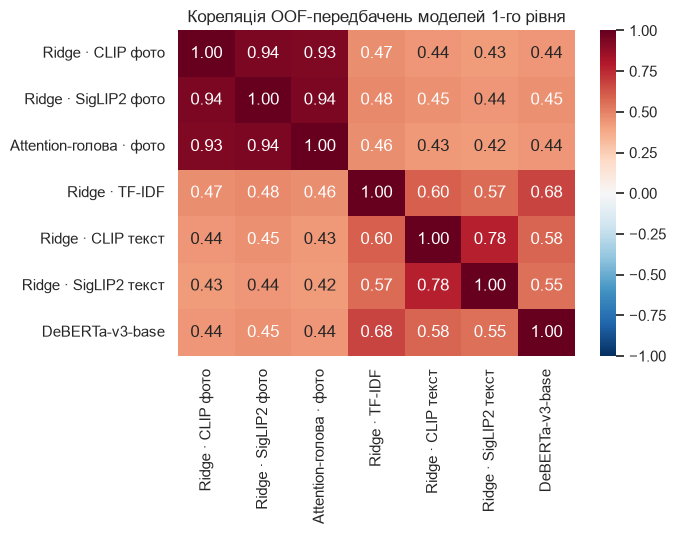

In [3]:
# The less correlated the level-1 models, the more the stack can gain
corr = level1[:n_tr].rename(columns=LEVEL1).corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Кореляція OOF-передбачень моделей 1-го рівня"); plt.tight_layout();

## 1. Модель 2-го рівня: порівняння варіантів

- **лінійний бленд** — Ridge на 7 OOF-передбаченнях (найпростіший стекінг);
- **LightGBM тільки на OOF** моделей 1-го рівня;
- **LightGBM на ручних ознаках + OOF** (ознаки дають дереву контекст, напр. вік чи тип тварини).

In [4]:
from sklearn.linear_model import Ridge

Z = level1.values
lin_oof = np.zeros(n_tr)
for f in np.unique(folds):
    m = Ridge(alpha=1.0).fit(Z[:n_tr][folds != f], y[folds != f])
    lin_oof[folds == f] = m.predict(Z[:n_tr][folds == f])

LGB2 = dict(learning_rate=0.01, num_leaves=15, min_data_in_leaf=40)
X_l1 = level1
X_all = pd.concat([hand, level1], axis=1)
res_l1 = run_lgb_cv(X_l1[:n_tr], X_l1[n_tr:], y, folds, params=dict(LGB2, num_leaves=7, min_data_in_leaf=80), verbose=False)
res_all = run_lgb_cv(X_all[:n_tr], X_all[n_tr:], y, folds, params=LGB2, verbose=False)

pd.DataFrame([
    {"модель 2-го рівня": "лінійний бленд (Ridge на OOF)", "n_features": Z.shape[1], "OOF QWK": score(lin_oof)},
    {"модель 2-го рівня": "LightGBM на OOF", "n_features": X_l1.shape[1], "OOF QWK": res_l1["qwk"]},
    {"модель 2-го рівня": "LightGBM на ознаках + OOF", "n_features": X_all.shape[1], "OOF QWK": res_all["qwk"]},
]).round(4)

,модель 2-го рівня,n_features,OOF QWK
0,лінійний бленд (Ridge на OOF),7,0.6198
1,LightGBM на OOF,7,0.6178
2,LightGBM на ознаках + OOF,253,0.6214


## 2. Фінальна модель: LightGBM на ознаках + OOF, 5 сідів

Пороги підбираємо на OOF. Оскільки пороги й оцінка рахуються на тих самих даних,
додатково рахуємо **чесну оцінку**: пороги підбираються на 4 фолдах і застосовуються до 5-го.

In [5]:
SEEDS = [SEED + s for s in range(5)]
oof, pred_te_cv, imp, best_iters = np.zeros(n_tr), np.zeros(len(test)), 0, []
for s in SEEDS:
    res = run_lgb_cv(X_all[:n_tr], X_all[n_tr:], y, folds, params={**LGB2, "seed": s}, verbose=False)
    print(f"seed {s}: OOF QWK {res['qwk']:.4f}   best_iters {res['best_iters']}")
    oof += res["oof"] / len(SEEDS); pred_te_cv += res["test"] / len(SEEDS)
    imp = imp + res["importance"] / len(SEEDS); best_iters += res["best_iters"]

rounder = OptimizedRounder().fit(oof, y)
print(f"\n5-seed OOF QWK: {qwk(y, rounder.predict(oof)):.4f}   thresholds: {rounder.coef_.round(3)}")

nested = np.zeros(n_tr)
for f in np.unique(folds):
    nested[folds == f] = OptimizedRounder().fit(oof[folds != f], y[folds != f]).predict(oof[folds == f])
print(f"honest OOF QWK (thresholds fit on other folds): {qwk(y, nested):.4f}")
np.save(PROCESSED_DIR / "oof_final.npy", oof)

seed 42: OOF QWK 0.6214   best_iters [383, 355, 359, 318, 453]


seed 43: OOF QWK 0.6162   best_iters [391, 354, 426, 334, 410]


seed 44: OOF QWK 0.6226   best_iters [347, 415, 448, 339, 361]


seed 45: OOF QWK 0.6203   best_iters [349, 359, 417, 343, 444]


seed 46: OOF QWK 0.6210   best_iters [383, 302, 408, 462, 376]



5-seed OOF QWK: 0.6210   thresholds: [1.839 2.497 3.268]


honest OOF QWK (thresholds fit on other folds): 0.6124


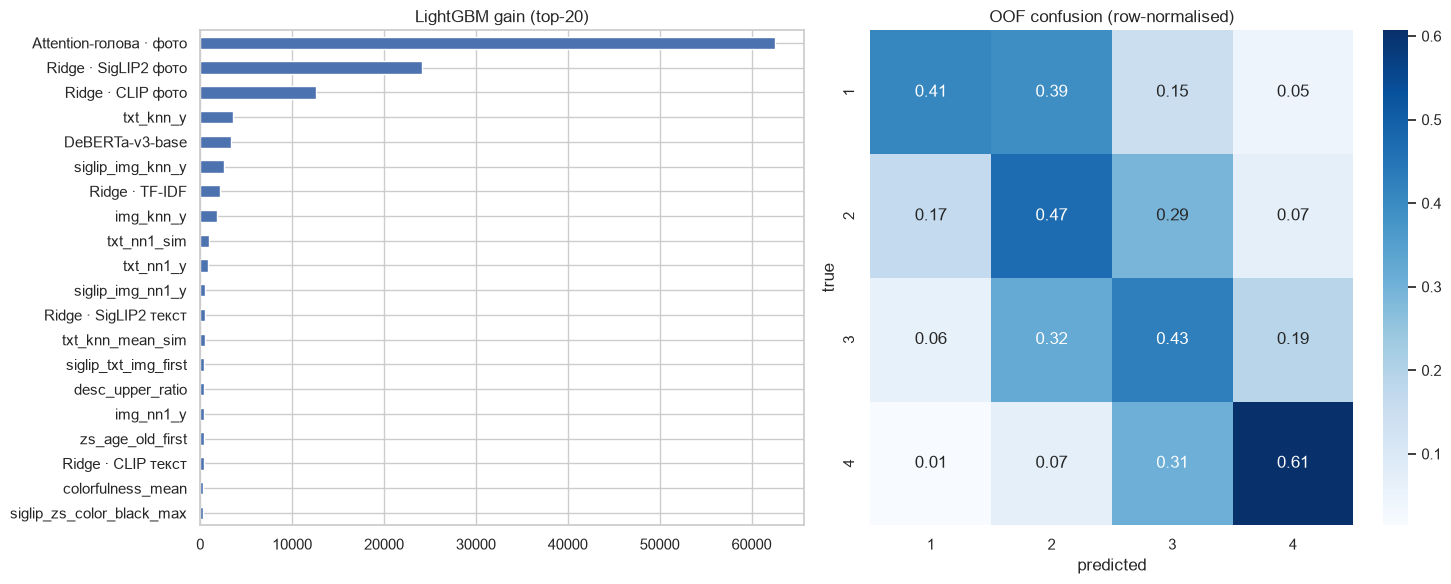

In [6]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
imp.rename(index=LEVEL1).sort_values(ascending=False).head(20).plot.barh(ax=axes[0], title="LightGBM gain (top-20)").invert_yaxis()
cm = confusion_matrix(y, rounder.predict(oof), labels=[1, 2, 3, 4], normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4], ax=axes[1])
axes[1].set(xlabel="predicted", ylabel="true", title="OOF confusion (row-normalised)")
plt.tight_layout();

## 3. Перенавчання на всіх розмічених даних

Модель 2-го рівня перенавчаємо на **всьому train** (у test міток немає) з кількістю ітерацій
із CV × 1.15 (даних на 25% більше, ніж у фолді). Входи для test — ті самі, що й у CV
(моделі 1-го рівня усереднені по фолдах), тож розподіл ознак train/test узгоджений.

In [7]:
n_rounds = int(np.mean(best_iters) * 1.15)
pred_te_full = np.zeros(len(test))
for s in SEEDS:
    model = fit_lgb_full(X_all[:n_tr], y, n_rounds, params={**LGB2, "seed": s})
    pred_te_full += model.predict(X_all[n_tr:]) / len(SEEDS)
print("rounds:", n_rounds)
print("corr(full refit, fold-average) on test:", np.corrcoef(pred_te_full, pred_te_cv)[0, 1].round(4))
np.save(PROCESSED_DIR / "test_final.npy", pred_te_full)

rounds: 438
corr(full refit, fold-average) on test: 0.9996


## 4. Сабмішн

Пороги — з OOF 5-сідового CV. Перевіряємо розподіл класів на test.

In [8]:
pred_cls = rounder.predict(pred_te_full)
dist = pd.DataFrame({
    "train (true)": pd.Series(y).value_counts(normalize=True),
    "OOF (pred)": pd.Series(rounder.predict(oof)).value_counts(normalize=True),
    "test, fold-avg (pred)": pd.Series(rounder.predict(pred_te_cv)).value_counts(normalize=True),
    "test, full refit (pred)": pd.Series(pred_cls).value_counts(normalize=True),
}).sort_index().round(3)
display(dist)
print("agreement full refit vs fold-average:", (pred_cls == rounder.predict(pred_te_cv)).mean().round(3))
write_submission(test[ID_COL], pred_cls, "07_final_stack");

,train (true),OOF (pred),"test, fold-avg (pred)","test, full refit (pred)"
1.0,0.186,0.140,0.152,0.156
2.0,0.276,0.293,0.265,0.259
3.0,0.206,0.298,0.269,0.264
4.0,0.332,0.268,0.314,0.321


agreement full refit vs fold-average: 0.979
Saved C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\submissions\07_final_stack.csv  shape=(1891, 2)
{1: 295, 2: 489, 3: 500, 4: 607}


## 5. Хід експериментів (OOF QWK)

In [9]:
history = pd.DataFrame([
    ("02", "текст: regex + мета", 0.246),
    ("02", "+ kNN-target по тексту", 0.319),
    ("03", "фото: CLIP zero-shot + якість + kNN", 0.558),
    ("04", "бейзлайн: ручні ознаки + SVD/PCA + Ridge-стекінг (public LB 0.7912)", 0.6125),
    ("05", "DeBERTa-v3-base окремо", 0.3445),
    ("03§6", "стек + SigLIP2", 0.617),
    ("06", "attention-голова окремо", 0.6112),
    ("07", "фінальний стек, 5 сідів", round(qwk(y, rounder.predict(oof)), 4)),
    ("07", "фінальний стек, чесні пороги", round(qwk(y, nested), 4)),
], columns=["ноутбук", "крок", "OOF QWK"])
history

,ноутбук,крок,OOF QWK
0,02,текст: regex + мета,0.2460
1,02,+ kNN-target по тексту,0.3190
2,03,фото: CLIP zero-shot + якість + kNN,0.5580
3,04,бейзлайн: ручні ознаки + SVD/PCA + Ridge-стекінг (public LB 0.7912),0.6125
4,05,DeBERTa-v3-base окремо,0.3445
5,03§6,стек + SigLIP2,0.6170
6,06,attention-голова окремо,0.6112
7,07,"фінальний стек, 5 сідів",0.6210
8,07,"фінальний стек, чесні пороги",0.6124


## Висновки

_(напишемо разом на етапі фіналізації)_